In [16]:
# ROI Simulation Parameters
campaign_cost_per_cust = 15.00  # Cost to target a customer ($)
success_rate = 0.20             # 20% conversion/retention rate

# Filter target group: Predicted Churners in High/Medium CLV Tiers
target_customers = rfm_summary[
    (rfm_summary["is_churned"] == 1) & 
    (rfm_summary["clv_tier"].isin(["High Value", "Medium Value"]))
]

num_targeted = len(target_customers)
total_campaign_cost = num_targeted * campaign_cost_per_cust

# Revenue saved from retained customers
retained_customers_count = num_targeted * success_rate
gross_revenue_recovered = target_customers["clv"].mean() * retained_customers_count
net_profit = gross_revenue_recovered - total_campaign_cost
roi = (net_profit / total_campaign_cost) * 100

print("--- FINANCIAL RETENTION CAMPAIGN SIMULATION ---")
print(f"Targeted At-Risk Customers: {num_targeted}")
print(f"Total Campaign Cost: ${total_campaign_cost:,.2f}")
print(f"Projected Saved Customers (20% conversion): {int(retained_customers_count)}")
print(f"Gross Revenue Recovered: ${gross_revenue_recovered:,.2f}")
print(f"Net Revenue Gain: ${net_profit:,.2f}")
print(f"Projected Campaign ROI: {roi:.2f}%")

--- FINANCIAL RETENTION CAMPAIGN SIMULATION ---
Targeted At-Risk Customers: 313
Total Campaign Cost: $4,695.00
Projected Saved Customers (20% conversion): 62
Gross Revenue Recovered: $66,467.51
Net Revenue Gain: $61,772.51
Projected Campaign ROI: 1315.71%


In [15]:
import pandas as pd
import numpy as np

# Calculate Historical CLV (annualized spending value)
rfm_summary["clv"] = rfm_summary["monetary"] * (rfm_summary["tenure_days"] / 365)

# Define CLV Tiers based on quantiles
rfm_summary["clv_tier"] = pd.qcut(
    rfm_summary["clv"], q=3, labels=["Low Value", "Medium Value", "High Value"]
)

# Aggregate CLV and Churn metrics across Tiers
clv_summary = rfm_summary.groupby("clv_tier").agg(
    total_customers=("customer_id", "count"),
    churn_rate=("is_churned", "mean"),
    avg_clv=("clv", "mean"),
    avg_monetary=("monetary", "mean"),
    avg_frequency=("frequency", "mean")
).reset_index()

# Format churn rate as percentage
clv_summary["churn_rate"] = (clv_summary["churn_rate"] * 100).round(2).astype(str) + "%"
clv_summary["avg_clv"] = clv_summary["avg_clv"].round(2)
clv_summary["avg_monetary"] = clv_summary["avg_monetary"].round(2)
clv_summary["avg_frequency"] = clv_summary["avg_frequency"].round(2)

print("--- CUSTOMER LIFETIME VALUE (CLV) TIER ANALYSIS ---")
display(clv_summary)

--- CUSTOMER LIFETIME VALUE (CLV) TIER ANALYSIS ---


C:\Users\Administrator\AppData\Local\Temp\ipykernel_18560\1891926250.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clv_summary = rfm_summary.groupby("clv_tier").agg(


,clv_tier,total_customers,churn_rate,avg_clv,avg_monetary,avg_frequency
0,Low Value,334,69.16%,296.55,186.63,3.28
1,Medium Value,332,50.6%,735.86,405.36,5.00
2,High Value,334,43.41%,1499.07,678.28,6.72


C:\Users\Administrator\AppData\Local\Temp\ipykernel_18560\3143613141.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x="Coefficient", y="Feature", palette="viridis")


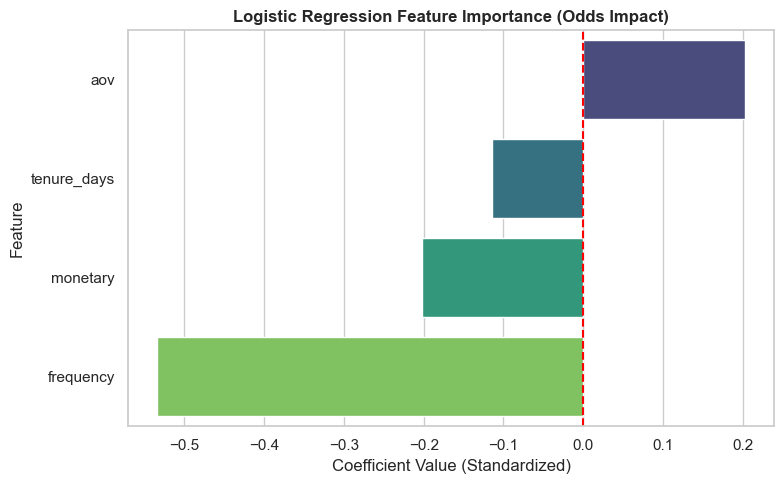

--- MODEL COEFFICIENTS ---


,Feature,Coefficient
2,aov,0.202353
3,tenure_days,-0.114314
1,monetary,-0.202298
0,frequency,-0.533975


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract coefficients from the trained Logistic Regression model
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": log_reg.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

# Plot feature impact
plt.figure(figsize=(8, 5))
sns.barplot(data=coef_df, x="Coefficient", y="Feature", palette="viridis")
plt.title("Logistic Regression Feature Importance (Odds Impact)", fontsize=12, fontweight="bold")
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Coefficient Value (Standardized)")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../reports/figures/feature_importance.png", dpi=300)
plt.show()

print("--- MODEL COEFFICIENTS ---")
display(coef_df)

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and fit Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on test set
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate performance metrics
print("--- RANDOM FOREST EVALUATION ---")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

--- RANDOM FOREST EVALUATION ---
ROC-AUC Score: 0.7319

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.57      0.62        91
           1       0.69      0.78      0.73       109

    accuracy                           0.69       200
   macro avg       0.68      0.68      0.68       200
weighted avg       0.68      0.69      0.68       200



In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Initialize and fit Logistic Regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Make predictions on test set
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

# Evaluate performance metrics
print("--- LOGISTIC REGRESSION EVALUATION ---")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

--- LOGISTIC REGRESSION EVALUATION ---
ROC-AUC Score: 0.7452

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.47      0.56        91
           1       0.65      0.82      0.72       109

    accuracy                           0.66       200
   macro avg       0.67      0.64      0.64       200
weighted avg       0.66      0.66      0.65       200



In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Select numerical predictor features (excluding IDs, dates, and target variable)
feature_cols = ["frequency", "monetary", "aov", "tenure_days"]
X = rfm_summary[feature_cols]
y = rfm_summary["is_churned"]

# Perform 80/20 Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standardize features (Mean=0, Std=1) for distance-based algorithms
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data successfully split!")
print(f"Training set shape: {X_train.shape} | Test set shape: {X_test.shape}")

Data successfully split!
Training set shape: (800, 4) | Test set shape: (200, 4)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_18560\140212112.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(["Retained (0)", "Churned (1)"])
C:\Users\Administrator\AppData\Local\Temp\ipykernel_18560\140212112.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(["Retained (0)", "Churned (1)"])


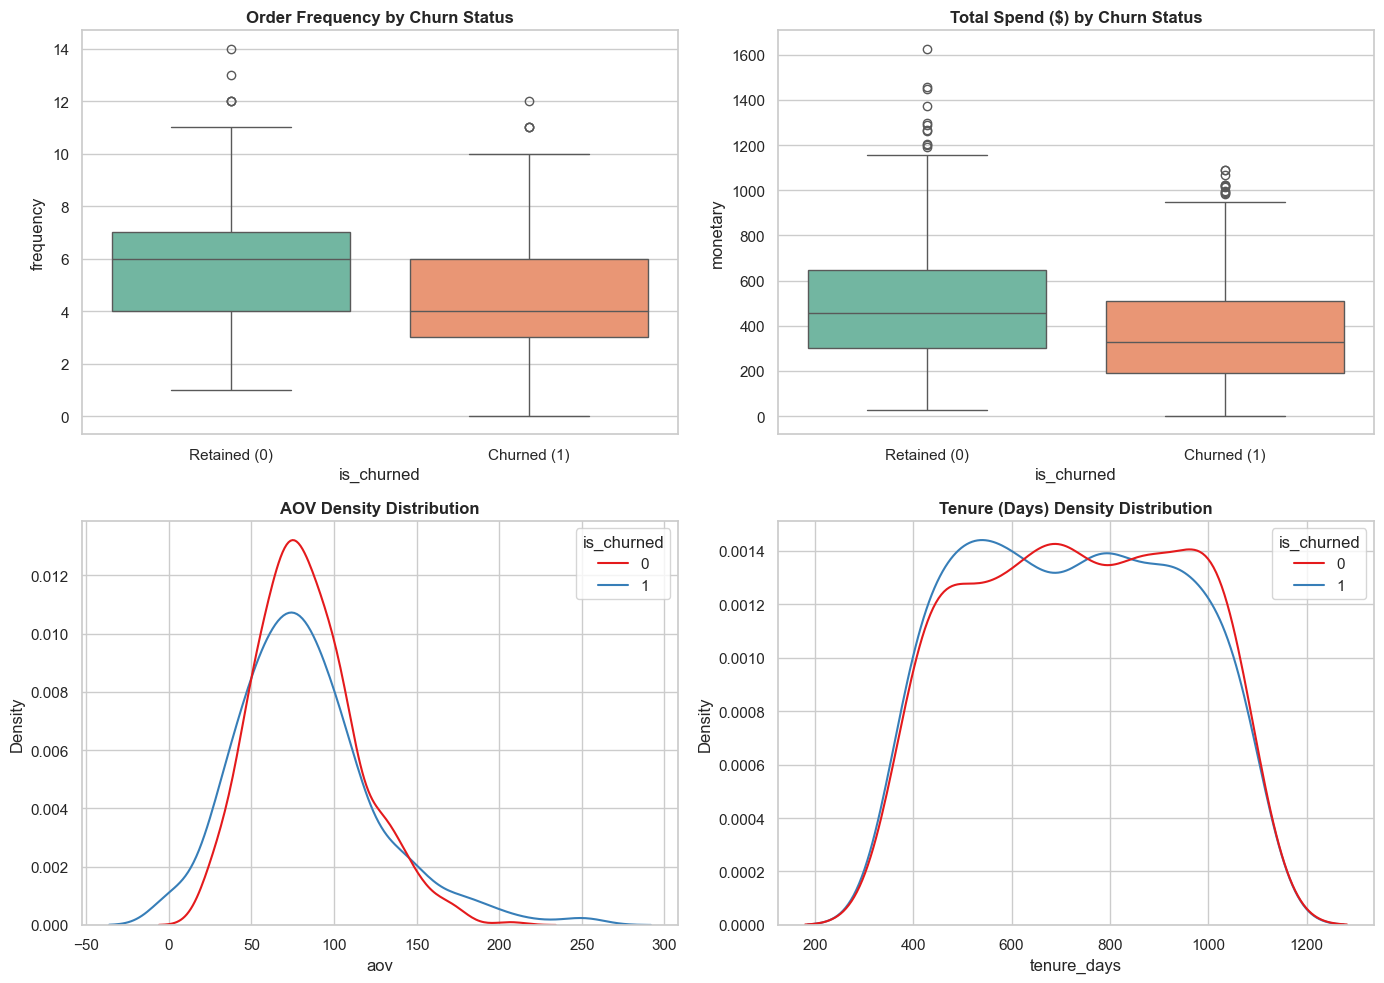

In [10]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure export directory exists
os.makedirs("../reports/figures", exist_ok=True)

# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Frequency Distribution
sns.boxplot(data=rfm_summary, x="is_churned", y="frequency", hue="is_churned", ax=axes[0, 0], palette="Set2", legend=False)
axes[0, 0].set_title("Order Frequency by Churn Status", fontsize=12, fontweight="bold")
axes[0, 0].set_xticklabels(["Retained (0)", "Churned (1)"])

# 2. Monetary Distribution
sns.boxplot(data=rfm_summary, x="is_churned", y="monetary", hue="is_churned", ax=axes[0, 1], palette="Set2", legend=False)
axes[0, 1].set_title("Total Spend ($) by Churn Status", fontsize=12, fontweight="bold")
axes[0, 1].set_xticklabels(["Retained (0)", "Churned (1)"])

# 3. Average Order Value (AOV) Distribution
sns.kdeplot(data=rfm_summary, x="aov", hue="is_churned", common_norm=False, ax=axes[1, 0], palette="Set1")
axes[1, 0].set_title("AOV Density Distribution", fontsize=12, fontweight="bold")

# 4. Customer Tenure Distribution
sns.kdeplot(data=rfm_summary, x="tenure_days", hue="is_churned", common_norm=False, ax=axes[1, 1], palette="Set1")
axes[1, 1].set_title("Tenure (Days) Density Distribution", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/figures/eda_feature_distributions.png", dpi=300)
plt.show()

In [8]:
from scipy import stats

# Separate metrics into two groups
retained = rfm_summary[rfm_summary["is_churned"] == 0]
churned = rfm_summary[rfm_summary["is_churned"] == 1]

metrics = ["frequency", "monetary", "aov", "tenure_days"]
ttest_results = []

for metric in metrics:
    t_stat, p_val = stats.ttest_ind(retained[metric], churned[metric], equal_var=False)
    ttest_results.append({
        "Metric": metric,
        "Retained Mean": round(retained[metric].mean(), 2),
        "Churned Mean": round(churned[metric].mean(), 2),
        "t-statistic": round(t_stat, 4),
        "p-value": round(p_val, 4),
        "Significant (α=0.05)": "Yes" if p_val < 0.05 else "No"
    })

results_df = pd.DataFrame(ttest_results)
print("--- TWO-SAMPLE T-TEST RESULTS ---")
display(results_df)

--- TWO-SAMPLE T-TEST RESULTS ---


,Metric,Retained Mean,Churned Mean,t-statistic,p-value,Significant (α=0.05)
0,frequency,5.83,4.30,10.9033,0.0000,Yes
1,monetary,493.09,365.09,7.9620,0.0000,Yes
2,aov,83.60,82.77,0.3587,0.7199,No
3,tenure_days,736.98,725.07,0.8894,0.3740,No


In [7]:
# Group by churn status and compute key statistical metrics
churn_comparison = rfm_summary.groupby("is_churned")[["recency", "frequency", "monetary", "aov", "tenure_days"]].agg(["mean", "median", "std"])

print("--- STATISTICAL METRICS BY CHURN STATUS ---")
display(churn_comparison)

--- STATISTICAL METRICS BY CHURN STATUS ---


recency                    frequency                   \
                  mean median         std      mean median       std   
is_churned                                                             
0            40.776316   39.0   26.143273  5.833333    6.0  2.244081   
1           239.825368  184.0  166.415323  4.301471    4.0  2.174928   

              monetary                             aov                        \
                  mean   median         std       mean     median        std   
is_churned                                                                     
0           493.091338  455.415  267.582059  83.603621  79.993125  31.127734   
1           365.089890  329.140  234.910084  82.768332  78.201125  42.355189   

           tenure_days                     
                  mean median         std  
is_churned                                 
0           736.982456  735.5  210.537626  
1           725.068015  725.0  211.537712

In [6]:
import pandas as pd

# Load the processed master dataset
rfm_summary = pd.read_csv("../data/processed/customer_churn_engineered.csv")

# Run group statistical comparison
churn_comparison = rfm_summary.groupby("is_churned")[["recency", "frequency", "monetary", "aov", "tenure_days"]].agg(["mean", "median", "std"])

print("--- STATISTICAL METRICS BY CHURN STATUS ---")
display(churn_comparison)

--- STATISTICAL METRICS BY CHURN STATUS ---


recency                    frequency                   \
                  mean median         std      mean median       std   
is_churned                                                             
0            40.776316   39.0   26.143273  5.833333    6.0  2.244081   
1           239.825368  184.0  166.415323  4.301471    4.0  2.174928   

              monetary                             aov                        \
                  mean   median         std       mean     median        std   
is_churned                                                                     
0           493.091338  455.415  267.582059  83.603621  79.993125  31.127734   
1           365.089890  329.140  234.910084  82.768332  78.201125  42.355189   

           tenure_days                     
                  mean median         std  
is_churned                                 
0           736.982456  735.5  210.537626  
1           725.068015  725.0  211.537712

In [5]:
# Calculate Customer Tenure in days
rfm_summary["tenure_days"] = (snapshot_date - rfm_summary["signup_date"]).dt.days

# Calculate Average Order Value (AOV), handling division by zero for 0-frequency users
rfm_summary["aov"] = np.where(
    rfm_summary["frequency"] > 0, 
    rfm_summary["monetary"] / rfm_summary["frequency"], 
    0
)

# Save the engineered master dataset to data/processed/
rfm_summary.to_csv("../data/processed/customer_churn_engineered.csv", index=False)

print("Feature engineering complete! Master dataset saved to data/processed/customer_churn_engineered.csv")
display(rfm_summary[["customer_id", "tenure_days", "aov", "recency", "frequency", "monetary", "is_churned"]].head())

NameError: name 'snapshot_date' is not defined

In [ ]:
# Define churn threshold (90 days of inactivity)
CHURN_THRESHOLD_DAYS = 90

# Create binary churn label (1 = Churned, 0 = Retained)
rfm_summary["is_churned"] = (rfm_summary["recency"] > CHURN_THRESHOLD_DAYS).astype(int)

# Check target variable distribution
churn_counts = rfm_summary["is_churned"].value_counts()
churn_pct = rfm_summary["is_churned"].value_counts(normalize=True) * 100

print("--- CHURN TARGET DISTRIBUTION ---")
print(f"Retained (0): {churn_counts.get(0, 0)} ({churn_pct.get(0, 0):.2f}%)")
print(f"Churned  (1): {churn_counts.get(1, 0)} ({churn_pct.get(1, 0):.2f}%)")

# Inspect updated dataset summary
display(rfm_summary.head())

--- CHURN TARGET DISTRIBUTION ---
Retained (0): 456 (45.60%)
Churned  (1): 544 (54.40%)


,customer_id,signup_date,gender,age,region,recency,frequency,monetary,is_churned
0,CUST-1000,2023-01-01 00:00:00.000000000,Male,64,East,9.0,9.0,443.47,0
1,CUST-1001,2023-01-01 17:32:15.135135135,Female,29,South,306.0,1.0,42.00,1
2,CUST-1002,2023-01-02 11:04:30.270270270,Female,33,East,16.0,5.0,292.85,0
3,CUST-1003,2023-01-03 04:36:45.405405405,Female,41,East,190.0,3.0,540.66,1
4,CUST-1004,2023-01-03 22:09:00.540540540,Male,36,South,251.0,4.0,267.25,1


In [ ]:
# Set snapshot reference date as 1 day after the latest transaction in dataset
snapshot_date = df_merged["transaction_date"].max() + pd.Timedelta(days=1)

# Aggregating per customer to compute RFM metrics
rfm = df_merged.groupby("customer_id").agg({
    "transaction_date": lambda x: (snapshot_date - x.max()).days, # Recency
    "transaction_id": "count",                                    # Frequency
    "order_amount": "sum"                                         # Monetary Value
}).reset_index()

# Rename columns for clarity
rfm.columns = ["customer_id", "recency", "frequency", "monetary"]

# Merge RFM features back with customer demography
rfm_summary = pd.merge(customers, rfm, on="customer_id", how="left")

# Fill missing RFM values for customers with zero transactions
rfm_summary["recency"] = rfm_summary["recency"].fillna(999)
rfm_summary["frequency"] = rfm_summary["frequency"].fillna(0)
rfm_summary["monetary"] = rfm_summary["monetary"].fillna(0)

print("RFM Metrics calculated successfully!")
display(rfm_summary.head())

RFM Metrics calculated successfully!


,customer_id,signup_date,gender,age,region,recency,frequency,monetary
0,CUST-1000,2023-01-01 00:00:00.000000000,Male,64,East,9.0,9.0,443.47
1,CUST-1001,2023-01-01 17:32:15.135135135,Female,29,South,306.0,1.0,42.00
2,CUST-1002,2023-01-02 11:04:30.270270270,Female,33,East,16.0,5.0,292.85
3,CUST-1003,2023-01-03 04:36:45.405405405,Female,41,East,190.0,3.0,540.66
4,CUST-1004,2023-01-03 22:09:00.540540540,Male,36,South,251.0,4.0,267.25


In [ ]:
# Merge transactions with customer demographic profile
df_merged = pd.merge(
    transactions, 
    customers, 
    on="customer_id", 
    how="inner"
)

# Inspect merged shape and first few rows
print(f"Merged Dataset Shape: {df_merged.shape}")
display(df_merged.head())

Merged Dataset Shape: (5000, 9)


,transaction_id,customer_id,transaction_date,order_amount,category,signup_date,gender,age,region
0,TXN-10000,CUST-1661,2024-01-01 00:00:00.000000000,32.54,Electronics,2024-04-28 00:18:44.324324320,Female,43,West
1,TXN-10001,CUST-1272,2024-01-01 03:30:16.923384676,10.12,Home & Kitchen,2023-07-18 18:12:36.756756756,Female,32,West
2,TXN-10002,CUST-1836,2024-01-01 07:00:33.846769353,45.42,Beauty,2024-09-02 21:22:52.972972968,Female,59,East
3,TXN-10003,CUST-1619,2024-01-01 10:30:50.770154030,73.43,Books,2024-03-28 07:44:08.648648648,Female,43,South
4,TXN-10004,CUST-1650,2024-01-01 14:01:07.693538707,58.86,Books,2024-04-19 23:23:57.837837840,Male,18,South


In [ ]:
# Convert date columns to datetime data types
customers["signup_date"] = pd.to_datetime(customers["signup_date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

# Verify duplicate records
cust_dupes = customers.duplicated().sum()
txn_dupes = transactions.duplicated().sum()

print(f"Customer duplicates: {cust_dupes}")
print(f"Transaction duplicates: {txn_dupes}")

# Verify data types after conversion
print("\n--- Updated Data Types ---")
print("Customers signup_date:", customers["signup_date"].dtype)
print("Transactions transaction_date:", transactions["transaction_date"].dtype)

Customer duplicates: 0
Transaction duplicates: 0

--- Updated Data Types ---
Customers signup_date: datetime64[ns]
Transactions transaction_date: datetime64[ns]


In [ ]:
# Load raw datasets
customers = pd.read_csv("../data/raw/customers_raw.csv")
transactions = pd.read_csv("../data/raw/transactions_raw.csv")

# Quick structure and null value check
print("--- CUSTOMERS INFO ---")
print(customers.info())
print("\n--- TRANSACTIONS INFO ---")
print(transactions.info())

# Display first 5 rows of each
display(customers.head())
display(transactions.head())


--- CUSTOMERS INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  1000 non-null   object
 1   signup_date  1000 non-null   object
 2   gender       1000 non-null   object
 3   age          1000 non-null   int64 
 4   region       1000 non-null   object
dtypes: int64(1), object(4)
memory usage: 39.2+ KB
None

--- TRANSACTIONS INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    5000 non-null   object 
 1   customer_id       5000 non-null   object 
 2   transaction_date  5000 non-null   object 
 3   order_amount      5000 non-null   float64
 4   category          5000 non-null   object 
dtypes: float64(1), object(4)
memory usage: 195.4+ KB
None


,customer_id,signup_date,gender,age,region
0,CUST-1000,2023-01-01 00:00:00.000000000,Male,64,East
1,CUST-1001,2023-01-01 17:32:15.135135135,Female,29,South
2,CUST-1002,2023-01-02 11:04:30.270270270,Female,33,East
3,CUST-1003,2023-01-03 04:36:45.405405405,Female,41,East
4,CUST-1004,2023-01-03 22:09:00.540540540,Male,36,South


,transaction_id,customer_id,transaction_date,order_amount,category
0,TXN-10000,CUST-1661,2024-01-01 00:00:00.000000000,32.54,Electronics
1,TXN-10001,CUST-1272,2024-01-01 03:30:16.923384676,10.12,Home & Kitchen
2,TXN-10002,CUST-1836,2024-01-01 07:00:33.846769353,45.42,Beauty
3,TXN-10003,CUST-1619,2024-01-01 10:30:50.770154030,73.43,Books
4,TXN-10004,CUST-1650,2024-01-01 14:01:07.693538707,58.86,Books


In [ ]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate Customer Profiles
n_customers = 1000
customer_ids = [f"CUST-{1000 + i}" for i in range(n_customers)]
signup_dates = pd.date_range(start="2023-01-01", end="2024-12-31", periods=n_customers)
gender = np.random.choice(["Male", "Female"], size=n_customers, p=[0.48, 0.52])
age = np.random.randint(18, 65, size=n_customers)
region = np.random.choice(["North", "South", "East", "West"], size=n_customers)

customers_df = pd.DataFrame({
    "customer_id": customer_ids,
    "signup_date": signup_dates,
    "gender": gender,
    "age": age,
    "region": region
})

# Save raw customer profiles to data/raw/
customers_df.to_csv("../data/raw/customers_raw.csv", index=False)

# Generate Transaction Records
n_transactions = 5000
trans_customer_ids = np.random.choice(customer_ids, size=n_transactions)
trans_dates = pd.date_range(start="2024-01-01", end="2025-12-31", periods=n_transactions)
order_amounts = np.round(np.random.exponential(scale=75, size=n_transactions) + 10, 2)
categories = np.random.choice(["Electronics", "Apparel", "Home & Kitchen", "Beauty", "Books"], size=n_transactions)

transactions_df = pd.DataFrame({
    "transaction_id": [f"TXN-{10000 + i}" for i in range(n_transactions)],
    "customer_id": trans_customer_ids,
    "transaction_date": trans_dates,
    "order_amount": order_amounts,
    "category": categories
})

# Save raw transactions to data/raw/
transactions_df.to_csv("../data/raw/transactions_raw.csv", index=False)

print("Dataset generated and saved successfully to data/raw/!")
print(f"Customers shape: {customers_df.shape}")
print(f"Transactions shape: {transactions_df.shape}")

Dataset generated and saved successfully to data/raw/!
Customers shape: (1000, 5)
Transactions shape: (5000, 5)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

print("Setup successful! All core libraries are loaded.")

Setup successful! All core libraries are loaded.
